In [1]:
import json
import re
import numpy as np
import pandas as pd
from tqdm import tqdm
from matplotlib import pyplot as plt
import tensorflow as tf
import autokeras as ak
from sklearn.model_selection import train_test_split

2023-12-28 14:25:40.751799: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-12-28 14:25:41.024147: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2023-12-28 14:25:41.024178: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2023-12-28 14:25:41.073272: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2023-12-28 14:25:41.173732: I tensorflow/core/platform/cpu_feature_guar

Using TensorFlow backend


In [ ]:
f = open('data/problems MoonBoard 2016 .json')
data = json.load(f)

In [3]:
data['data'][0]

{'name': 'Far from the Madding Crowd',
 'grade': '6B+',
 'userGrade': '6B+',
 'setbyId': '5FC09F63-05F3-4DAE-A1A5-3AC22C37139A',
 'setby': 'Ben Moon',
 'method': 'Feet follow hands',
 'userRating': 4,
 'repeats': 26756,
 'holdsetup': {'description': 'MoonBoard 2016', 'holdsets': None, 'apiId': 1},
 'isBenchmark': True,
 'isMaster': False,
 'upgraded': False,
 'downgraded': False,
 'moves': [{'problemId': 19215,
   'description': 'E6',
   'isStart': True,
   'isEnd': False},
  {'problemId': 19215, 'description': 'C5', 'isStart': True, 'isEnd': False},
  {'problemId': 19215, 'description': 'E8', 'isStart': False, 'isEnd': False},
  {'problemId': 19215, 'description': 'F11', 'isStart': False, 'isEnd': False},
  {'problemId': 19215, 'description': 'C13', 'isStart': False, 'isEnd': False},
  {'problemId': 19215, 'description': 'D15', 'isStart': False, 'isEnd': False},
  {'problemId': 19215, 'description': 'D18', 'isStart': False, 'isEnd': True}],
 'holdsets': [{'description': 'Hold Set B', 

In [4]:
def get_hold_list(moves):
    hold_list = []
    for move in moves:
        hold_list.append(move['description'])
    return hold_list

In [5]:

#problem_array = np.empty([len(data['data']), 5], dtype='S')
problem_df = pd.DataFrame(columns=['name', 'grade', 'userGrade', 'apiId', 'moves'])
for i, problem in tqdm(enumerate(data['data']), total = len(data['data'])):
    name = problem['name']
    grade = problem['grade']
    userGrade = problem['userGrade']
    apiId = problem['apiId']
    hold_list = get_hold_list(problem['moves'])
    problem_df.loc[i] = [name, grade, userGrade, apiId, hold_list]
print(problem_df.head)

100%|██████████| 63388/63388 [01:44<00:00, 604.58it/s] 

<bound method NDFrame.head of                              name grade userGrade   apiId  \
0      Far from the Madding Crowd   6B+       6B+   19215   
1               Wuthering Heights   6B+       6B+   19216   
2                       Problem 3   6B+       6B+   19217   
3                      HARD TIMES    7A        7A   19218   
4                       Problem 5    7A        7A   19219   
...                           ...   ...       ...     ...   
63383                Just Dawg It    7A      None  475159   
63384             DIAGONAL DANGLE   7A+       7A+  475161   
63385         the warmup's warmup   6B+       6B+  475162   
63386      PRETTY STRAIGHTFORWARD   6C+      None  475163   
63387            Shorty Warm Up 5   6B+      None  475166   

                                                moves  
0                    [E6, C5, E8, F11, C13, D15, D18]  
1                   [F5, J8, I11, K11, G13, E15, E18]  
2                    [F5, J5, F9, C10, G13, E15, I18]  
3            

In [6]:
all_holds = problem_df['moves'].sum()

In [7]:
unique_holds = set(all_holds)
print(unique_holds)
unique_holds = list(unique_holds)
print(unique_holds)
unique_holds.sort()
print(unique_holds)

{'I14', 'A18', 'J5', 'A10', 'K11', 'I9', 'B10', 'E6', 'C13', 'I15', 'J10', 'F10', 'E7', 'E14', 'B13', 'G13', 'K9', 'A16', 'C11', 'D15', 'K6', 'H7', 'J11', 'J13', 'C7', 'F16', 'B7', 'A13', 'D7', 'G11', 'I5', 'D11', 'j5', 'I6', 'E10', 'G6', 'I11', 'K10', 'E16', 'A9', 'K13', 'C14', 'D9', 'B12', 'F14', 'I4', 'H8', 'C6', 'E15', 'D18', 'B3', 'K18', 'F13', 'H18', 'H15', 'J7', 'G16', 'H14', 'K14', 'G9', 'H10', 'C12', 'D3', 'C16', 'G4', 'G14', 'A11', 'A15', 'G17', 'J8', 'G7', 'I18', 'B11', 'C8', 'J9', 'A6', 'G10', 'G2', 'C15', 'F6', 'B18', 'A14', 'K7', 'H11', 'C9', 'J12', 'I13', 'G8', 'J16', 'H5', 'E8', 'B6', 'D10', 'D6', 'E12', 'K12', 'D5', 'F12', 'K5', 'H9', 'F7', 'I8', 'B16', 'J14', 'H16', 'B4', 'D17', 'J6', 'F11', 'I12', 'D14', 'H13', 'G12', 'F5', 'F9', 'G18', 'J2', 'G15', 'D12', 'A5', 'B9', 'E13', 'E18', 'C18', 'D13', 'I7', 'H12', 'C10', 'B15', 'D8', 'F8', 'F15', 'C5', 'I10', 'A12', 'E9', 'I16', 'K16', 'E11', 'K8', 'B8', 'D16'}
['I14', 'A18', 'J5', 'A10', 'K11', 'I9', 'B10', 'E6', 'C13', '

In [8]:
def letter_to_number(letter):
    # Convert the letter to uppercase to handle both cases
    letter = letter.upper()

    # Check if the input is a valid uppercase letter
    if letter.isalpha() and len(letter) == 1:
        # ASCII value of 'A' is 65, so subtracting it gives the position in the alphabet
        return ord(letter) - ord('A') + 1
    else:
        # Return None for invalid input
        return None

def hold_to_coord(hold_string):
    pattern = r'\d+'
    match = re.search(pattern, hold_string)
    x = int(match.group())
    pattern = r'[a-zA-Z]+'
    match = re.search(pattern, hold_string)
    y = match.group()
    y = letter_to_number(y)
    return [x, y]

In [9]:
cumulative_holds = np.zeros(shape = (18,11))

for hold in tqdm(all_holds):
    hold_coord = hold_to_coord(hold)
    cumulative_holds[hold_coord[0] - 1, hold_coord[1] - 1] +=1

100%|██████████| 480586/480586 [00:00<00:00, 826889.65it/s]


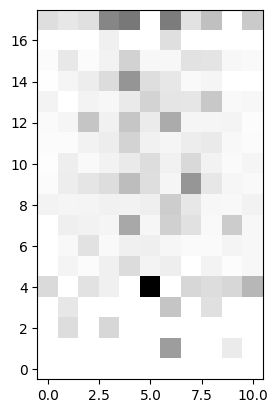

In [10]:
plt.imshow(cumulative_holds, cmap="Greys", interpolation="nearest", origin="lower")
plt.show()

In [11]:
problem_df['userGrade'].unique()

array(['6B+', '7A', '7B', '6C+', '7A+', '7B+', '6C', '7C', '7C+', None,
       '6B', '8A', '8B', '8A+', '8B+'], dtype=object)

In [12]:
grade_conversion = {'6B' : 1, 
                    '6B+' : 2, 
                    '6C': 3, 
                    '6C+': 4,
                    '7A': 5,
                    '7A+': 6,
                    '7B': 7,
                    '7B+': 8,
                    '7C': 9,
                    '7C+': 10,
                    '8A': 11,
                    '8A+': 12,
                    '8B': 13,
                    '8B+':14}

#Convert French Front Grade to a number
def grade_to_numeric(grade):
    grade_number = grade_conversion.get(grade)
    return grade_number

In [13]:
#grade_to_numeric(problem_df['userGrade'])
problem_df['userGradeNumeric'] = problem_df['userGrade'].apply(lambda x: grade_conversion.get(x))
problem_df['gradeNumeric'] = problem_df['grade'].apply(lambda x: grade_conversion.get(x))

In [14]:
def problem_holds_to_array(all_holds):
    problem_array = np.zeros((18,11))
    for hold in all_holds:
        hold_coord = hold_to_coord(hold)
        problem_array[hold_coord[0] - 1, hold_coord[1] - 1] =1
    return problem_array

In [15]:
#build training data
num_of_problems = problem_df.shape[0]
x_all = np.zeros((num_of_problems, 18, 11))
y_all = np.zeros(num_of_problems)
for index, problem in tqdm(problem_df.iterrows(), total = problem_df.shape[0]):
    problem_array = problem_holds_to_array(problem['moves'])
    x_all[index,:,:] = problem_array
    y_all[index] = problem['gradeNumeric']


100%|██████████| 63388/63388 [00:02<00:00, 28829.04it/s]


In [16]:
x_train, x_test, y_train, y_test = train_test_split(x_all, y_all, test_size=1000, random_state=42)

In [17]:
reg = ak.ImageRegressor(overwrite=True, max_trials=1)
# Feed the image regressor with training data.
reg.fit(x_train, y_train, epochs=3)

Trial 1 Complete [00h 02m 36s]
val_loss: 2.1564159393310547

Best val_loss So Far: 2.1564159393310547
Total elapsed time: 00h 02m 36s
Epoch 1/3
1950/1950 [==============================] - 66s 28ms/step - loss: 3.0924 - mean_squared_error: 3.0924
Epoch 2/3
1950/1950 [==============================] - 49s 25ms/step - loss: 2.4525 - mean_squared_error: 2.4525
Epoch 3/3
1950/1950 [==============================] - 51s 26ms/step - loss: 2.7686 - mean_squared_error: 2.7686
INFO:tensorflow:Assets written to: ./image_regressor/best_model/assets


INFO:tensorflow:Assets written to: ./image_regressor/best_model/assets


In [18]:
# Predict with the best model.
predicted_y = reg.predict(x_test)
print(predicted_y)

32/32 [==============================] - 0s 5ms/step
[[2.4616594]
 [2.7527285]
 [6.2009263]
 [4.6485505]
 [3.2846692]
 [5.3042946]
 [3.1008947]
 [3.572329 ]
 [7.1403537]
 [6.514195 ]
 [2.5936427]
 [2.7479343]
 [5.4815154]
 [3.2727418]
 [3.1079953]
 [3.5232496]
 [2.3685968]
 [4.893982 ]
 [3.0042763]
 [4.8050976]
 [3.8351433]
 [2.5499327]
 [4.958437 ]
 [2.812873 ]
 [2.8646252]
 [4.2000904]
 [2.544629 ]
 [2.432201 ]
 [7.5725317]
 [3.1050172]
 [3.1356158]
 [3.9722314]
 [5.0848856]
 [2.7785995]
 [6.9553733]
 [4.3131585]
 [2.313468 ]
 [5.7082005]
 [2.9923406]
 [3.5712934]
 [2.8814826]
 [5.6089935]
 [2.5054955]
 [2.483957 ]
 [7.549737 ]
 [2.59427  ]
 [2.2238362]
 [2.7935154]
 [6.8752837]
 [4.692869 ]
 [2.598757 ]
 [2.3387496]
 [2.681861 ]
 [8.647712 ]
 [3.8176951]
 [7.389128 ]
 [2.9340773]
 [4.122813 ]
 [2.534797 ]
 [2.8236663]
 [5.413764 ]
 [2.4236784]
 [2.9069858]
 [6.2796288]
 [3.0995548]
 [2.4572637]
 [2.301726 ]
 [3.9485579]
 [2.81056  ]
 [5.481834 ]
 [3.3107438]
 [3.082189 ]
 [5.152355 

In [19]:
print(y_test)

[ 4.  3.  6.  3.  2.  6.  3.  4. 11.  2.  2.  4.  8.  5.  3.  3.  3.  7.
  3.  9.  2.  2.  3.  2.  2.  4.  2.  2.  6.  3.  3.  4.  9.  2.  5.  4.
  2.  6.  2.  6.  4.  7.  2.  2.  9.  3.  2.  2.  9.  2.  3.  2.  2. 10.
  6.  7.  4.  2.  2.  4.  5.  2.  5.  8.  2.  2.  2.  5.  3.  6.  6.  4.
  6.  5.  2.  6.  2.  4.  4.  8.  3.  4.  6.  4.  3.  2.  6.  4.  9.  8.
  3.  6.  2.  5.  8.  4.  3.  3.  7.  8.  6.  4.  2.  2.  2.  4.  2.  2.
  2.  5.  9.  5.  2.  4.  2.  2.  3. 14.  2.  6.  5.  8.  4.  2.  4.  2.
  2.  4.  5.  2.  4.  3.  8.  4.  2.  4.  3.  7.  7.  2.  2.  5.  4.  6.
  2.  2.  3.  2.  3.  2.  2.  4.  5.  8.  2.  2.  2.  4.  4.  3.  4.  5.
  2.  4.  2.  8.  5.  2.  3.  2.  2.  4.  2.  2.  2.  6.  5.  2.  5.  2.
  2.  2.  2.  6.  3.  2.  6.  7.  8.  2.  3.  5.  2.  2.  8.  2.  2.  7.
  7.  5.  6.  2.  3.  2.  7.  2.  3.  5.  2.  2.  6.  5.  2.  6.  6.  4.
  5.  2.  6.  3.  2.  2.  3.  6.  4.  3.  6.  3.  5.  2.  2.  4.  8.  2.
  3.  8.  3.  3.  8.  3.  4.  3.  6.  2.  2.  3.  8

In [20]:
print(reg.evaluate(x_test, y_test))

32/32 [==============================] - 1s 12ms/step - loss: 2.3899 - mean_squared_error: 2.3899
[2.3898727893829346, 2.3898727893829346]


In [21]:
print(np.shape(x_all))
print(np.shape(y_all))

print(y_all)

print(y_all[0])
print(y_all[2])



print(y_all[2])



(63388, 18, 11)
(63388,)
[2. 2. 2. ... 2. 4. 2.]
2.0
2.0
2.0
